In [ ]:
# 1. Fix library versions for audio stability
!pip install "datasets<4.0.0" librosa tqdm
!apt-get update && apt-get install -y ffmpeg

import numpy as np
import librosa
from datasets import load_dataset
from tqdm import tqdm
from sklearn.model_selection import train_test_split

# 2. Constants for high-quality deployment
SAMPLE_RATE = 16000
DURATION = 3
N_MELS = 128

# 3. Load and Map Labels
print("Fetching TORGO dataset...")
ds = load_dataset("abnerh/TORGO-database", split="train")

def map_labels(example):
    example['label'] = 1 if example['speech_status'] == 'dysarthria' else 0
    return example

ds = ds.map(map_labels)
print(f"Total samples available: {len(ds)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 15.1 MB/s eta 0:00:00
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,891 kB]
Hit:8 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:9 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [83.8 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/multiverse amd64

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00004.parquet:   0%|          | 0.00/370M [00:00<?, ?B/s]

data/train-00001-of-00004.parquet:   0%|          | 0.00/397M [00:00<?, ?B/s]

data/train-00002-of-00004.parquet:   0%|          | 0.00/356M [00:00<?, ?B/s]

data/train-00003-of-00004.parquet:   0%|          | 0.00/441M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16552 [00:00<?, ? examples/s]

Map:   0%|          | 0/16552 [00:00<?, ? examples/s]

Total samples available: 16552


In [ ]:
# Identify indices for both classes
healthy_indices = [i for i, x in enumerate(ds['speech_status']) if x != 'dysarthria']
dysarthric_indices = [i for i, x in enumerate(ds['speech_status']) if x == 'dysarthria']

print(f"Healthy samples found: {len(healthy_indices)}")
print(f"Dysarthric samples found: {len(dysarthric_indices)}")

# Select 2,500 from each for a total of 5,000 balanced images
# This ensures the model doesn't just learn to guess 'Healthy'
num_per_class = 2500
selected_indices = healthy_indices[:num_per_class] + dysarthric_indices[:num_per_class]

# Shuffle indices so the model doesn't see all healthy then all sick during extraction
import random
random.seed(42)
random.shuffle(selected_indices)

print(f"Balanced selection complete. Total to extract: {len(selected_indices)}")

Healthy samples found: 10978
Dysarthric samples found: 5574
Balanced selection complete. Total to extract: 5000


In [ ]:
def extract_mel_spectrogram(audio_array, sr=SAMPLE_RATE):
    # Ensure exact 3-second length
    target_length = DURATION * sr
    if len(audio_array) > target_length:
        audio_array = audio_array[:target_length]
    else:
        audio_array = np.pad(audio_array, (0, target_length - len(audio_array)))

    # Create the visual representation (Mel-Spectrogram)
    mel_spec = librosa.feature.melspectrogram(y=audio_array, sr=sr, n_mels=N_MELS)
    # Convert to log scale (Decibels) so the AI 'hears' like a human
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

    return mel_spec_db

In [ ]:
X = []
y = []

print("Extracting balanced spectrograms...")
for i in tqdm(selected_indices):
    try:
        audio_data = ds[i]['audio']['array']
        spec = extract_mel_spectrogram(audio_data)
        X.append(spec)
        y.append(ds[i]['label'])
    except Exception as e:
        continue

X = np.array(X)
y = np.array(y)

# Reshape for CNN: (Samples, Height, Width, Grayscale_Channel)
X = X.reshape(X.shape[0], X.shape[1], X.shape[2], 1)

print(f"\nExtraction Complete!")
print(f"New Feature Shape: {X.shape}")
print(f"New Label Distribution: {np.unique(y, return_counts=True)}")

Extracting balanced spectrograms...


100%|██████████| 5000/5000 [01:15<00:00, 66.37it/s] 



Extraction Complete!
New Feature Shape: (5000, 128, 94, 1)
New Label Distribution: (array([0, 1]), array([2500, 2500]))


In [ ]:
# Perform the 80/20 split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("--- Verified Stats for Your Project ---")
print(f"Total Training Images: {len(X_train)}")
print(f" -> Healthy in training: {np.sum(y_train == 0)}")
print(f" -> Dysarthria in training: {np.sum(y_train == 1)}")
print(f"\nTotal Testing Images: {len(X_test)}")
print(f" -> Healthy in testing: {np.sum(y_test == 0)}")
print(f" -> Dysarthria in testing: {np.sum(y_test == 1)}")

--- Verified Stats for Your Project ---
Total Training Images: 4000
 -> Healthy in training: 2000
 -> Dysarthria in training: 2000

Total Testing Images: 1000
 -> Healthy in testing: 500
 -> Dysarthria in testing: 500


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_dysarthria_model(input_shape):
    model = models.Sequential([
        # Layer 1: Detecting basic audio edges and shapes
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),

        # Layer 2: Detecting complex speech transitions
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Layer 3: Final high-level feature extraction
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.GlobalAveragePooling2D(), # Reduces parameters to prevent overfitting

        # Output: Decision making
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5), # Critical for small medical datasets to prevent memorization
        layers.Dense(1, activation='sigmoid') # Returns probability (0 = Healthy, 1 = Dysarthric)
    ])

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# Initialize the model using your extracted data shape
input_shape = (X_train.shape[1], X_test.shape[2], 1)
model = build_dysarthria_model(input_shape)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 92, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 46, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 44, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,993 (394.50 KB)

 Trainable params: 100,993 (394.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Stop training if the validation loss doesn't improve for 5 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("Starting training on balanced dataset...")
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Starting training on balanced dataset...
Epoch 1/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.5144 - loss: 0.7811 - val_accuracy: 0.7960 - val_loss: 0.4854
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8202 - loss: 0.3938 - val_accuracy: 0.9050 - val_loss: 0.2602
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9221 - loss: 0.2170 - val_accuracy: 0.9590 - val_loss: 0.1324
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9378 - loss: 0.1870 - val_accuracy: 0.9540 - val_loss: 0.1306
Epoch 5/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9565 - loss: 0.1230 - val_accuracy: 0.9680 - val_loss: 0.0951
Epoch 6/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9728 - loss: 0.0904 - val_accuracy: 0.9580 - val_loss: 0.1257
Epoch 7/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9495 - loss: 0.1340 - val_accuracy: 0.9740 - val_loss: 0.0826
Epoch 8/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - a

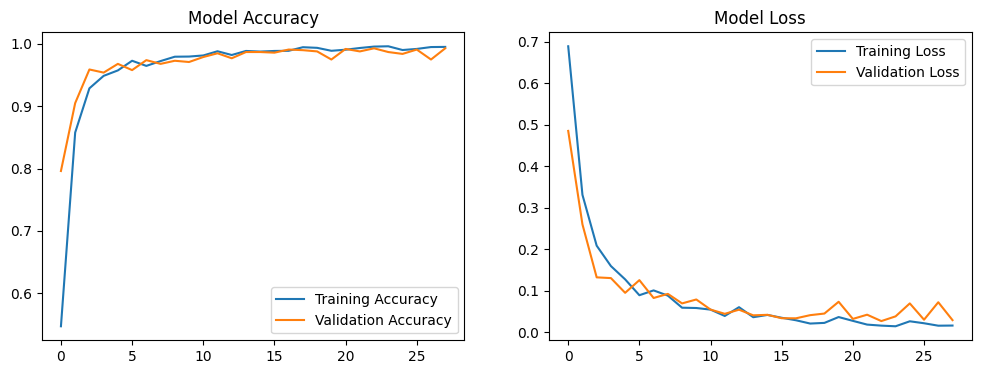


Final Test Accuracy: 99.30%


In [ ]:
import matplotlib.pyplot as plt

# Plot Training vs Validation Accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.legend()

# Plot Training vs Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.legend()

plt.show()

# Final Accuracy Score
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nFinal Test Accuracy: {test_acc*100:.2f}%")

In [ ]:
model.save('dysarthria_detection_model.h5')
print("Model saved as 'dysarthria_detection_model.h5'. You can now download this from the Colab file explorer.")

Model saved as 'dysarthria_detection_model.h5'. You can now download this from the Colab file explorer.


32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step


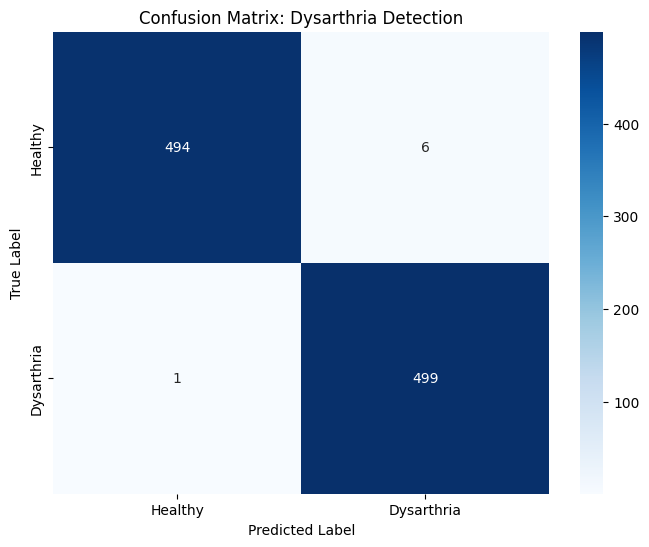


--- Detailed Classification Report ---
              precision    recall  f1-score   support

     Healthy       1.00      0.99      0.99       500
  Dysarthria       0.99      1.00      0.99       500

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Generate predictions for the test set
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int) # Convert probabilities to 0 or 1

# 2. Create the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# 3. Visualize it
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'Dysarthria'],
            yticklabels=['Healthy', 'Dysarthria'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Dysarthria Detection')
plt.show()

# 4. Detailed Classification Report (Precision, Recall, F1)
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Healthy', 'Dysarthria']))

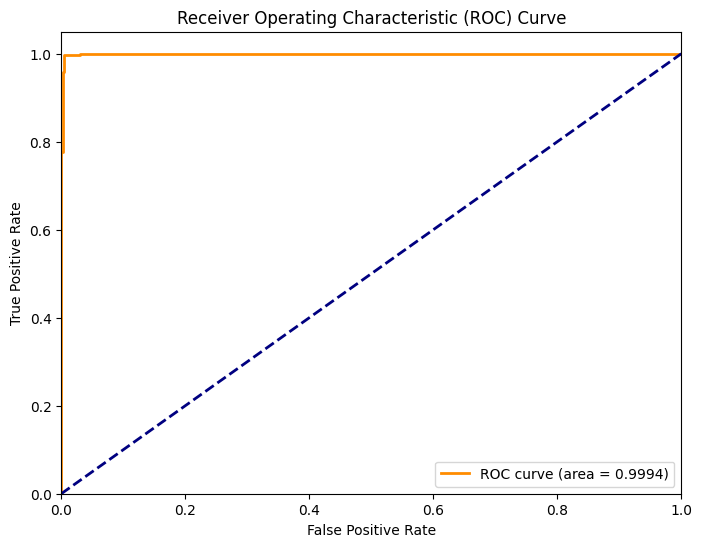

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()